# Hamiltonian Flow Matching — Obstacle Potential (2D)

Transports `N([-2,0], I)` → `N([2,0], I)` in 2D while **navigating around two Gaussian-bump obstacles**.

The conditional path uses `ParticleBVPGaussianPath`: for each OT-coupled pair `(x₀, x₁)`,
a Hamiltonian BVP `x'' = -∇V(x)` is solved to find the trajectory that connects them
while respecting the potential landscape.

**Workflow:**
1. OT-couple a fixed dataset `(x₀, x₁)`
2. `path.batch_solve(x0_dataset, x1_dataset)` — solve particle BVPs for all pairs
3. Train from index-based sampling of the cache

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import (
    ObstaclePotential, ParticleBVPGaussianPath,
    flow_matching_loss, plot_trajectories_with_potential,
)
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.models.models_v2 import MLP
from torchcfm.utils import torch_wrapper

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

dim        = 2
batch_size = 64
n_dataset  = 512   # number of pre-computed (x0, x1) pairs
n_iters    = 5000
lr         = 1e-3

# Obstacle parameters
alpha_obs  = 5.0
beta_obs   = 20.0
centers    = [[0, -1.5], [0, 1.5]]
sigma_path = 0.01

print(f'device: {device}')

device: cuda


## Distributions

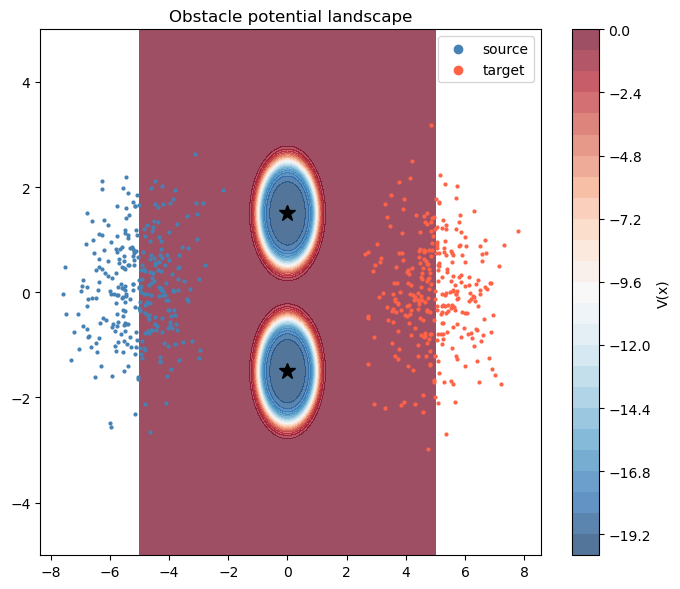

In [3]:
def sample_source(n):
    return torch.randn(n, 2) + torch.tensor([-5.0, 0.0])

def sample_target(n):
    return torch.randn(n, 2) + torch.tensor([5.0, 0.0])

potential = ObstaclePotential(alpha=alpha_obs, beta=beta_obs, centers=centers)

# Visualise potential landscape with source and target
g = np.linspace(-5, 5, 150)
X, Y = np.meshgrid(g, g)
xy = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)
Z = potential.energy(xy).numpy().reshape(150, 150)

x0_vis = sample_source(300); x1_vis = sample_target(300)

plt.figure(figsize=(7, 6))
plt.contourf(X, Y, Z, levels=30, cmap='RdBu_r', alpha=0.7)
plt.colorbar(label='V(x)')
plt.scatter(x0_vis[:, 0], x0_vis[:, 1], s=4, c='steelblue', label='source')
plt.scatter(x1_vis[:, 0], x1_vis[:, 1], s=4, c='tomato',    label='target')
for c in centers:
    plt.plot(c[0], c[1], 'k*', markersize=12)
plt.legend(markerscale=3); plt.title('Obstacle potential landscape')
plt.tight_layout(); plt.show()

## Path — pre-compute BVP dataset

In [4]:
path       = ParticleBVPGaussianPath(potential, sigma=sigma_path, n_steps=50, tol=0.1)
ot_sampler = OTPlanSampler(method='exact')

# Step 1: OT-couple the dataset
x0_all = sample_source(n_dataset)
x1_all = sample_target(n_dataset)
x0_coupled, x1_coupled = ot_sampler.sample_plan(x0_all, x1_all)

print(f'Solving {n_dataset} particle BVPs (may take several minutes)...')

# Step 2: Pre-compute BVP for all pairs
states = path.batch_solve(x0_coupled, x1_coupled)
print(f'Done. states: {states.shape}  (pairs, time-steps, state-dim [x, v])')

Solving 512 particle BVPs (may take several minutes)...


RuntimeError: SciPy particle BVP failed: The maximum number of mesh nodes is exceeded.

In [ ]:
# Visualise a few BVP-solved trajectories
n_show = min(50, n_dataset)
traj_bvp = states[:n_show, :, :dim].numpy()  # (pairs, time, x-position)

plt.figure(figsize=(7, 6))
plt.contourf(X, Y, Z, levels=30, cmap='RdBu_r', alpha=0.5)
for i in range(n_show):
    plt.plot(traj_bvp[i, :, 0], traj_bvp[i, :, 1], 'gray', alpha=0.4, linewidth=0.6)
plt.scatter(x0_coupled[:n_show, 0], x0_coupled[:n_show, 1], s=6, c='steelblue', label='x0')
plt.scatter(x1_coupled[:n_show, 0], x1_coupled[:n_show, 1], s=6, c='tomato', label='x1')
plt.legend(markerscale=2); plt.title('BVP reference trajectories')
plt.tight_layout(); plt.show()

## Model and training

In [ ]:
model     = MLP(dim + 1, out_dim=dim, w=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

x0_coupled = x0_coupled.to(device)
x1_coupled = x1_coupled.to(device)

model.train()
losses = []

for k in range(n_iters):
    optimizer.zero_grad()

    # Sample indices from the cached BVP solutions
    idx  = torch.randint(0, n_dataset, (batch_size,))
    x0_b = x0_coupled[idx]
    x1_b = x1_coupled[idx]

    t       = torch.rand((batch_size, 1), device=device)
    epsilon = torch.randn_like(x0_b)
    xt      = path.sample_xt(x0_b, x1_b, t, epsilon)
    ut      = path.compute_ut(x0_b, x1_b, t, xt)

    vt   = model(torch.cat([xt, t], dim=-1))
    loss = flow_matching_loss(vt, ut)

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if k % 1000 == 0 or k == n_iters - 1:
        print(f'step {k:5d}: loss = {loss.item():.5f}')

In [ ]:
plt.figure(figsize=(7, 3))
plt.semilogy(losses)
plt.xlabel('iteration'); plt.ylabel('loss'); plt.title('Training loss')
plt.tight_layout(); plt.show()

## Evaluation

In [ ]:
model.eval()
node = NeuralODE(torch_wrapper(model), sensitivity='adjoint', solver='euler')

with torch.no_grad():
    traj = node.trajectory(
        sample_source(500).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )

traj = traj.cpu()

# Use library diagnostic: trajectories overlaid on potential contour
fig = plot_trajectories_with_potential(traj.numpy(), X, Y, Z, n=500)
fig.suptitle('Learned trajectories navigating obstacles')
plt.tight_layout(); plt.show()

x1_ref = sample_target(500)
plt.figure(figsize=(6, 5))
plt.contourf(X, Y, Z, levels=30, cmap='RdBu_r', alpha=0.4)
plt.scatter(traj[-1, :, 0], traj[-1, :, 1], s=4, c='tomato', label='generated')
plt.scatter(x1_ref[:, 0], x1_ref[:, 1], s=4, c='seagreen', label='target')
plt.legend(markerscale=3); plt.title('Generated vs Target')
plt.tight_layout(); plt.show()

In [ ]:
# ρ₀ → ρ_t → ρ₁ on obstacle potential + individual trajectory paths
n_show = 500
n_lines = 200

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: all time-step positions scatter
cf = axes[0].contourf(X, Y, Z, levels=30, cmap='RdBu_r', alpha=0.7)
plt.colorbar(cf, ax=axes[0], label='V(x)')
axes[0].scatter(traj[0, :n_show, 0], traj[0, :n_show, 1],
                s=10, alpha=0.7, c='royalblue', label=r'$\rho_0$', zorder=3)
axes[0].scatter(traj[1:-1:5, :n_show, 0].reshape(-1), traj[1:-1:5, :n_show, 1].reshape(-1),
                s=0.3, alpha=0.15, c='black', label=r'$\rho_t$')
axes[0].scatter(traj[-1, :n_show, 0], traj[-1, :n_show, 1],
                s=10, alpha=0.7, c='tomato', label=r'$\rho_1$', zorder=3)
for c in centers:
    axes[0].plot(c[0], c[1], 'k*', markersize=12, zorder=4)
axes[0].legend(markerscale=4)
axes[0].set_title(r'$\rho_0 \to \rho_t \to \rho_1$  on obstacle potential')

# Right: individual trajectory lines
axes[1].contourf(X, Y, Z, levels=30, cmap='RdBu_r', alpha=0.5)
for i in range(n_lines):
    axes[1].plot(traj[:, i, 0], traj[:, i, 1], 'gray', alpha=0.2, linewidth=0.6)
for c in centers:
    axes[1].plot(c[0], c[1], 'k*', markersize=12, zorder=4)
axes[1].scatter(traj[0, :n_lines, 0], traj[0, :n_lines, 1], s=6, c='royalblue', zorder=3)
axes[1].scatter(traj[-1, :n_lines, 0], traj[-1, :n_lines, 1], s=6, c='tomato', zorder=3)
axes[1].set_title('Trajectory paths navigating obstacles')

plt.tight_layout(); plt.show()